In [5]:
# Imports & connections
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()
DB_URL = os.getenv('DATABASE_URL')
engine = create_engine(DB_URL)

In [6]:
# Which cause, for which the airport is made accountable, leads to how much delay by country per year?
query_delay_cause_airport = """
SELECT
    state_name,
    year,
    ROUND(SUM(dly_apt_arr_a_1), 0)  AS delay_atc_capacity,
    ROUND(SUM(dly_apt_arr_c_1), 0)  AS delay_staffing,
    ROUND(SUM(dly_apt_arr_w_1), 0)  AS delay_weather,
    ROUND(SUM(dly_apt_arr_e_1), 0)  AS delay_equipment,
    ROUND(SUM(dly_apt_arr_s_1), 0)  AS delay_special_event,
    ROUND(SUM(dly_apt_arr_t_1), 0)  AS delay_routeing,
    ROUND(SUM(dly_apt_arr_g_1), 0)  AS delay_aerodrome,
    ROUND(SUM(dly_apt_arr_m_1), 0)  AS delay_met,
    ROUND(SUM(dly_apt_arr_i_1), 0)  AS delay_industrial_action,
    ROUND(SUM(dly_apt_arr_na_1), 0) AS delay_unclassified,
    ROUND(SUM(dly_apt_arr_1), 0)    AS total_delay
FROM fact_airport_delay
GROUP BY state_name, year
ORDER BY year DESC, total_delay DESC;
"""

df_delay_cause_airport = pd.read_sql(query_delay_cause_airport, engine)


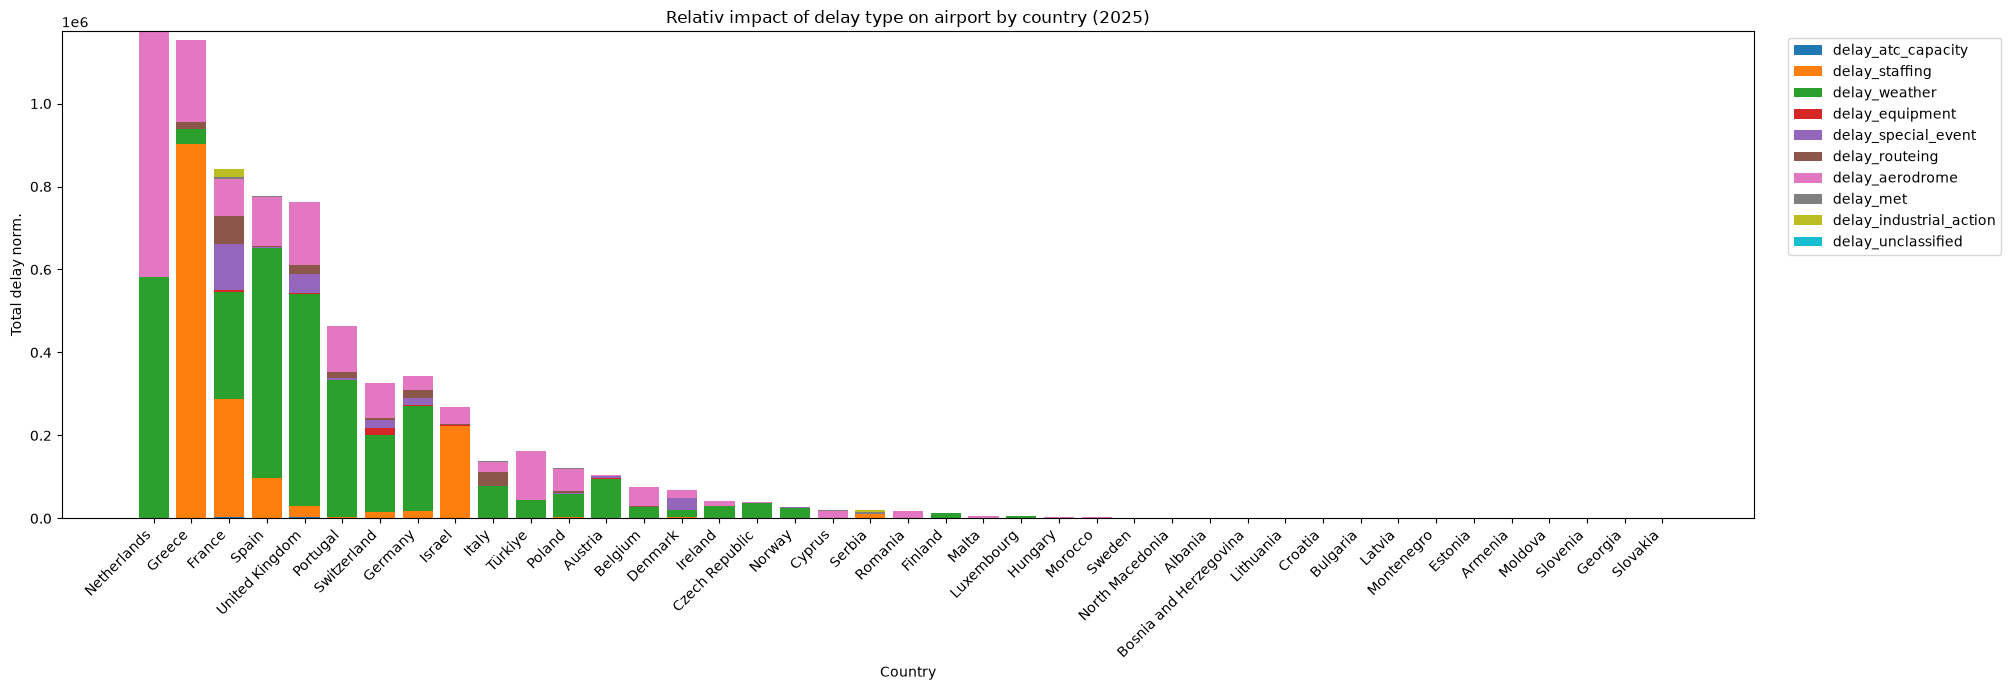

In [7]:
## Analysis & Visualisation
# check which rows contain NaN
# df_delay_cause_airport[df_delay_cause_airport.isna().any(axis=1)]
# -> 92 rows
# validate if entire row is NaN
# display(df_delay_cause_airport[df_delay_cause_airport.isna().any(axis=1)].tail(50))
# display(df_delay_cause_airport[df_delay_cause_airport.isna().any(axis=1)].head(50))
# -> all of the 92 rows contain just NaN in the delay type columns
# -> keep, because NaN will not be displayed in the visual and the data remains original.

# Set year filter

year_filter = 2025
df_delay_cause_airport_filtered = df_delay_cause_airport[df_delay_cause_airport["year"] == year_filter]

# Define delay types in a list
delay_cols = [
    "delay_atc_capacity", "delay_staffing", "delay_weather", "delay_equipment",
    "delay_special_event", "delay_routeing", "delay_aerodrome", "delay_met",
    "delay_industrial_action", "delay_unclassified"
]

# Plot
fig, ax = plt.subplots(figsize=(20, 7))

bottom = [0] * len(df_delay_cause_airport_filtered)

for col in delay_cols:
    ax.bar(df_delay_cause_airport_filtered["state_name"], df_delay_cause_airport_filtered[col], label=col, bottom=bottom)
    bottom = [b + v for b, v in zip(bottom, df_delay_cause_airport_filtered[col].fillna(0))]

ax.set_xlabel("Country")
ax.set_ylabel("Total delay norm.")
ax.set_title(f"Relativ impact of delay type on airport by country ({year_filter})")
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Relativ impact of delay type on airport by country 2025
- western EU countries had an overall higher impact on its airports due to delays, especially impacted by weather
- Greece main delay type was due to staffing
- the smaller countries and also the eastern part of the EU showed less delays in total

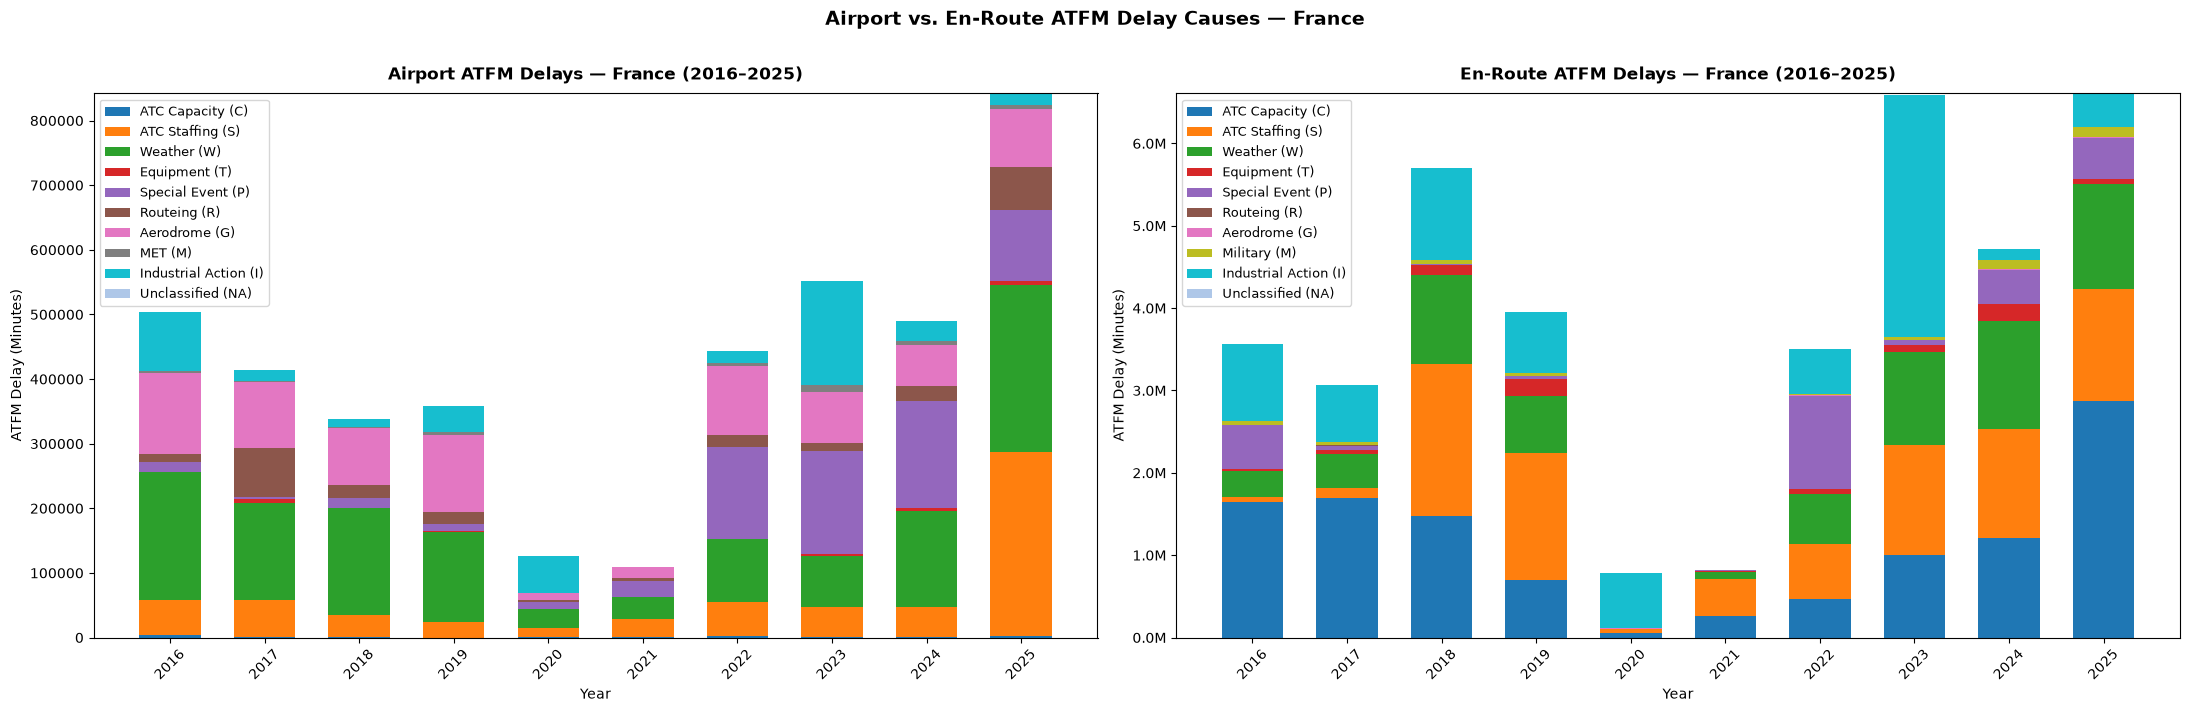

In [8]:
# ── Deep Dive France ─────────────────────────────────────────

# ── Data: En-Route France ──
query_enroute_france = """
SELECT
    e.year,
    ROUND(SUM(e.dly_ert_c_1), 0)  AS delay_atc_capacity,
    ROUND(SUM(e.dly_ert_s_1), 0)  AS delay_staffing,
    ROUND(SUM(e.dly_ert_w_1), 0)  AS delay_weather,
    ROUND(SUM(e.dly_ert_t_1), 0)  AS delay_equipment,
    ROUND(SUM(e.dly_ert_p_1), 0)  AS delay_special_event,
    ROUND(SUM(e.dly_ert_r_1), 0)  AS delay_routeing,
    ROUND(SUM(e.dly_ert_g_1), 0)  AS delay_aerodrome,
    ROUND(SUM(e.dly_ert_m_1), 0)  AS delay_military,
    ROUND(SUM(e.dly_ert_i_1), 0)  AS delay_industrial_action,
    ROUND(SUM(e.dly_ert_na_1), 0) AS delay_unclassified
FROM fact_enroute_delay e
JOIN dim_entity_region r ON e.entity_name = r.entity_name
WHERE r.iso_country = 'FR'
  AND e.year BETWEEN 2016 AND 2025
  AND e.entity_type = 'ANSP (AUA)'
GROUP BY e.year
ORDER BY e.year
"""
df_enroute_france = pd.read_sql(query_enroute_france, engine)

# ── Data: Airport France ──
df_airport_france = df_delay_cause_airport[
    (df_delay_cause_airport["state_name"] == "France") &
    (df_delay_cause_airport["year"].between(2016, 2025, inclusive="both"))
].copy()

# ── Labels ──

delay_labels = {
    "delay_atc_capacity":      "ATC Capacity (C)",
    "delay_staffing":          "ATC Staffing (S)",
    "delay_weather":           "Weather (W)",
    "delay_equipment":         "Equipment (T)",
    "delay_special_event":     "Special Event (P)",
    "delay_routeing":          "Routeing (R)",
    "delay_aerodrome":         "Aerodrome (G)",
    "delay_met":               "MET (M)",
    "delay_military":          "Military (M)",
    "delay_industrial_action": "Industrial Action (I)",
    "delay_unclassified":      "Unclassified (NA)",
}

airport_cols  = [c for c in delay_labels.keys() if c in df_airport_france.columns]
enroute_cols  = [c for c in delay_labels.keys() if c in df_enroute_france.columns]

COLOR_MAP = {
    "delay_atc_capacity":      "#1f77b4",
    "delay_staffing":          "#ff7f0e",
    "delay_weather":           "#2ca02c",
    "delay_equipment":         "#d62728",
    "delay_special_event":     "#9467bd",
    "delay_routeing":          "#8c564b",
    "delay_aerodrome":         "#e377c2",
    "delay_met":               "#7f7f7f",
    "delay_military":          "#bcbd22",
    "delay_industrial_action": "#17becf",
    "delay_unclassified":      "#aec7e8",
}

# ── Plot ──

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

for ax, df, cols, title in [
    (axes[0], df_airport_france, airport_cols, "Airport ATFM Delays — France (2016–2025)"),
    (axes[1], df_enroute_france, enroute_cols, "En-Route ATFM Delays — France (2016–2025)"),
]:
    bottom = [0] * len(df)
    for col in cols:
        if col not in df.columns:
            continue
        ax.bar(df["year"], df[col].fillna(0),
               label=delay_labels[col],
               color=COLOR_MAP[col],          # ← fixe Farbe
               bottom=bottom, width=0.65)
        bottom = [b + v for b, v in zip(bottom, df[col].fillna(0))]

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("ATFM Delay (Minutes)")
    ax.set_xticks(df["year"])
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc="upper left", fontsize=9)

axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

plt.suptitle("Airport vs. En-Route ATFM Delay Causes — France",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Key Takeaways: Airport vs. En-Route ATFM Delay Causes, France (2016–2025)**
- **Two fundamentally different delay profiles:**  
Airport delays are driven by external factors (weather, industrial action at airports), while en-route delays are driven by internal ANSP failures — structural ATC capacity and staffing shortfalls at DSNA.
- **DSNA strikes are a recurring structural problem:**  
Industrial Action (I) appears as a significant en-route driver in 2016, 2018, 2023, and 2025. This is not a one-off event but a systemic issue within French airspace management.
- **2018 en-route peak was strike-driven:**  
In 2018, DSNA strikes alone caused over 1 million minutes of en-route delay (~19% of France's total en-route ATFM delay that year), despite traffic volumes being lower than post-COVID peaks.
- **COVID-19 impact visible in both plots (2020–2021):**  
Delays collapsed to roughly 25% of pre-pandemic levels but never reached zero. The en-route profile during COVID is almost entirely unclassified/residual, confirming that structural capacity issues disappeared with traffic.
- **Post-COVID delays exceed pre-pandemic levels:**  
By 2023, both airport and en-route delays surpassed 2016–2019 averages, suggesting infrastructure and staffing capacity did not scale with the traffic recovery.
- **2025 is the worst year in the dataset:**  
2025 reached record highs in both airport and en-route delays, driven by Industrial Action on the en-route side and a combination of Weather and Industrial Action on the airport side.

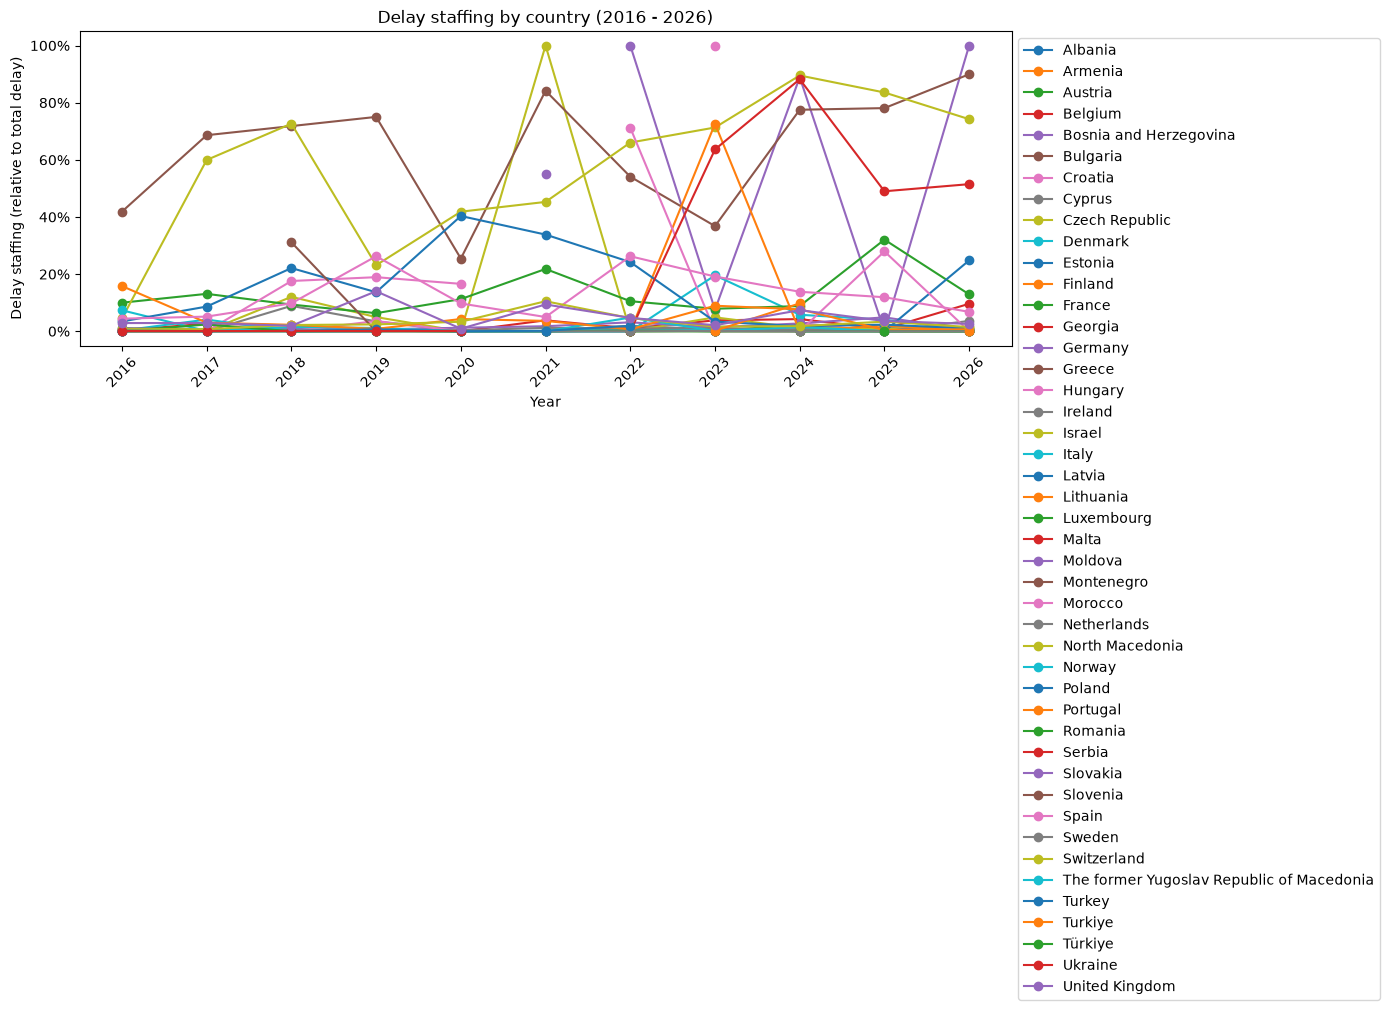

In [10]:
# impact of epidemic (corona) by comparing corona period to non-corona 
df_delay_cause_airport = df_delay_cause_airport.groupby(["state_name", "year"]).sum()

df_delay_cause_airport_reset = df_delay_cause_airport.reset_index()

# Define year range
years_def = range(2016, 2027)

fig, ax = plt.subplots(figsize=(14, 6))

for country, group in df_delay_cause_airport_reset.groupby("state_name"):
    # Reindex auf alle Jahre, fehlende Jahre = 0
    group = group.set_index("year").reindex(years_def) # ,fill_value=0
    ratio = group["delay_staffing"] / group["total_delay"].replace(0, float("nan")) # if ratio = 0, plot is skipped
    ax.plot(years_def, ratio, label=country, marker="o")

ax.set_xlabel("Year")
ax.set_ylabel("Delay staffing (relative to total delay)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title(f"Delay staffing by country ({years_def[0]} - {years_def[-1]})")
ax.set_xticks(years_def)
# ax.set_yscale("log")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
n_countries = df_delay_cause_airport_reset["state_name"].nunique()
fig.set_size_inches(14, max(6, n_countries * 1))
plt.show()

In [11]:
# Which cause, for which the airspace of the airport is made accountable, leads to how much delay by country per year?
# Optional: include months to have a closer look
query_delay_cause_airspace = """
SELECT
    er.country_name,
    ed.year,
    ed.month_num,
    ROUND(SUM(ed.dly_ert_a_1), 0)  AS delay_atc_capacity,
    ROUND(SUM(ed.dly_ert_c_1), 0)  AS delay_staffing,
    ROUND(SUM(ed.dly_ert_w_1), 0)  AS delay_weather,
    ROUND(SUM(ed.dly_ert_e_1), 0)  AS delay_equipment,
    ROUND(SUM(ed.dly_ert_s_1), 0)  AS delay_special_event,
    ROUND(SUM(ed.dly_ert_t_1), 0)  AS delay_routeing,
    ROUND(SUM(ed.dly_ert_g_1), 0)  AS delay_aerodrome,
    ROUND(SUM(ed.dly_ert_m_1), 0)  AS delay_met,
    ROUND(SUM(ed.dly_ert_i_1), 0)  AS delay_industrial_action,
    ROUND(SUM(ed.dly_ert_na_1), 0) AS delay_unclassified,
    ROUND(SUM(ed.dly_ert_1), 0)    AS total_delay
FROM fact_enroute_delay ed
INNER JOIN dim_entity_region er USING(entity_name)
GROUP BY er.country_name, ed.year, ed.month_num
ORDER BY ed.year DESC, total_delay DESC;
"""

df_delay_cause_airspace = pd.read_sql(query_delay_cause_airspace, engine)
df_delay_cause_airspace = df_delay_cause_airspace.dropna(how='any')

In [12]:
# Year filter
df_delay_cause_airspace_year = df_delay_cause_airspace.groupby(["country_name", "year"]).sum()
df_delay_cause_airspace_year = df_delay_cause_airspace_year.drop(columns=["month_num"])

In [13]:
df_delay_cause_airspace_year.head(20)

delay_atc_capacity  delay_staffing  delay_weather  \
country_name year                                                      
Albania      2017                 0.0             0.0            0.0   
             2018                 0.0             0.0            0.0   
             2019                 0.0             0.0            0.0   
             2021                 0.0             0.0            0.0   
             2022                 0.0           119.0            0.0   
             2023                 0.0             0.0         1530.0   
             2024                 0.0          3663.0        22964.0   
             2025                 0.0          4326.0         3829.0   
Austria      2016                 0.0          2956.0        44901.0   
             2017                 0.0         39762.0       174522.0   
             2018                 0.0        203294.0       445029.0   
             2019                 0.0        626018.0       717487.0   
             2020                 0.0            85.0            4.0   
             2021                 0.0             0.0          951.0   
             2022                 0.0         11849.0        58202.0   
             2023                 0.0         39963.0        96871.0   
             2024                 0.0        107897.0       433439.0   
             2025                 0.0         35978.0       282019.0   
             2026                 0.0             5.0         1978.0   
Azerbaijan   2026                 0.0             0.0            0.0   

                   delay_equipment  delay_special_event  delay_routeing  \
country_name year                                                         
Albania      2017              0.0                  0.0            80.0   
             2018              0.0                  0.0             0.0   
             2019              0.0                  0.0             0.0   
             2021              0.0                 33.0             0.0   
             2022              0.0                  0.0             0.0   
             2023              0.0                  0.0           302.0   
             2024              0.0                  0.0          3704.0   
             2025              0.0                  0.0          3145.0   
Austria      2016              0.0               5525.0             0.0   
             2017              0.0              30742.0             0.0   
             2018              0.0             156470.0          1446.0   
             2019              0.0             403059.0           287.0   
             2020              0.0                  0.0             0.0   
             2021              0.0                  0.0             0.0   
             2022              0.0              34785.0            41.0   
             2023              0.0              26743.0             0.0   
             2024              0.0              98452.0           805.0   
             2025              0.0             231080.0             0.0   
             2026              0.0                  0.0             0.0   
Azerbaijan   2026              0.0                147.0             0.0   

                   delay_aerodrome  delay_met  delay_industrial_action  \
country_name year                                                        
Albania      2017              0.0        0.0                      0.0   
             2018              0.0        0.0                      0.0   
             2019              0.0      195.0                      0.0   
             2021              0.0        0.0                      0.0   
             2022              0.0        0.0                      0.0   
             2023              0.0        0.0                      0.0   
             2024            202.0        0.0                      0.0   
             2025              0.0        0.0                      0.0   
Austria      2016              0.0        0

/tmp/ipykernel_22243/1759003708.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, tick_labels=countries_delay_cause_airspace, vert=True)


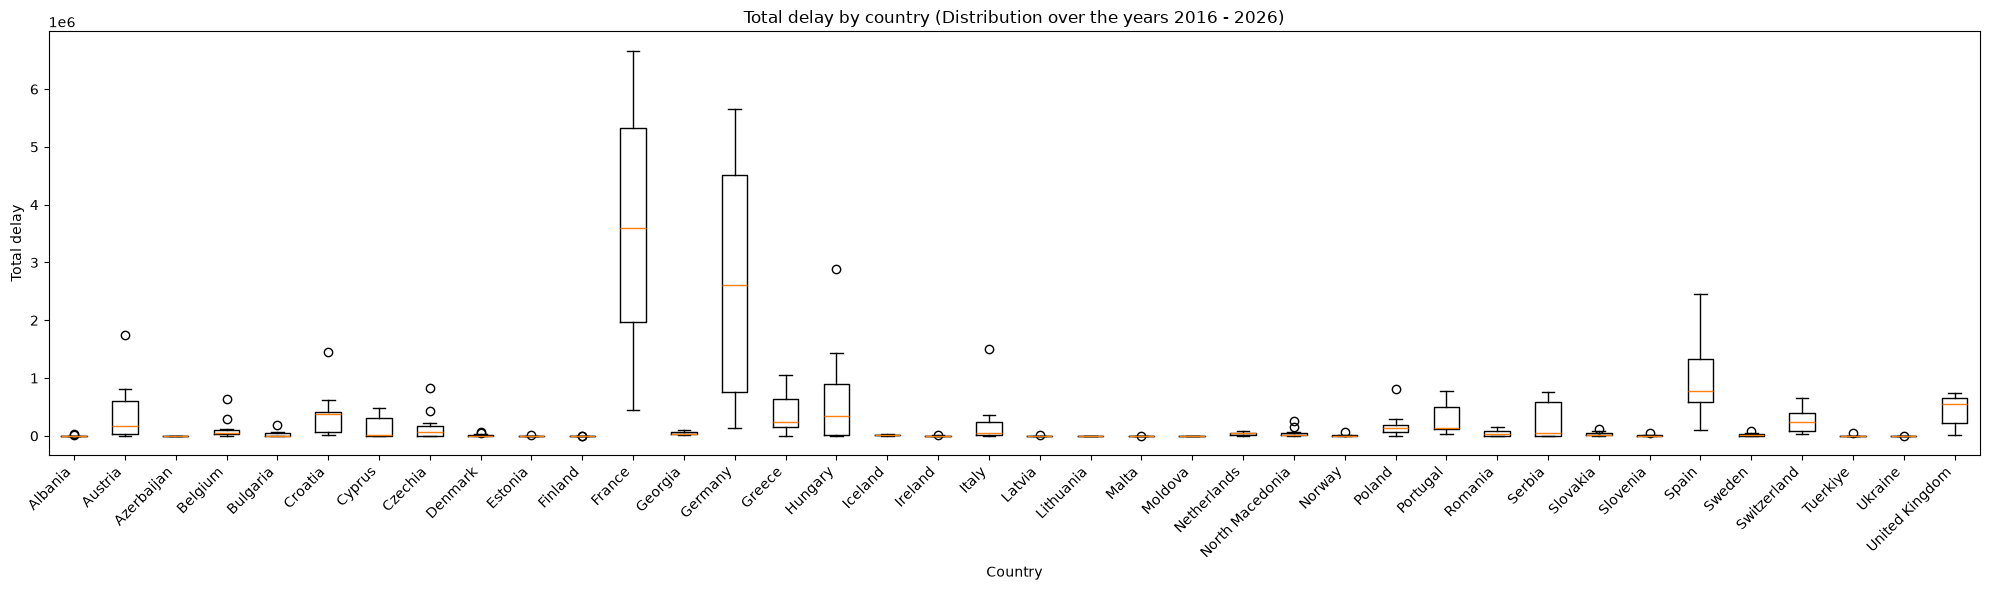

In [14]:
# Reset index
df_delay_cause_airspace_year_reset = df_delay_cause_airspace_year.reset_index()

# countries
countries_delay_cause_airspace = df_delay_cause_airspace_year_reset["country_name"].unique()

# Boxplot data: one array per country
data = [df_delay_cause_airspace_year_reset[df_delay_cause_airspace_year_reset["country_name"] == c]["total_delay"].values for c in countries_delay_cause_airspace]

# Plot
fig, ax = plt.subplots(figsize=(20, 6))

ax.boxplot(data, tick_labels=countries_delay_cause_airspace, vert=True)

ax.set_xlabel("Country")
ax.set_ylabel("Total delay")
ax.set_title("Total delay by country (Distribution over the years 2016 - 2026)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Total delay comparison by country for the airspace (en-route) over the entire data period of 10 years (2016 - 2026)

- not only do France and Germany have the highest total delays for their airspace compared to the other counries, but also the broadest distribution over the given time period.
- a few countries had some outliers
-  Austria 2019 (staffing, weather, special event), Croatia 2024 (staffing, weather, routeing), Czechia 2022 (routeing), Hungary 2024 (weather, routeing), Italy 2024 (staffing, weather, routeing), Poland 2022 (aerodrome & met)

In [29]:
country = "Austria"   

outlier = (
    df_delay_cause_airspace_year_reset
    .loc[df_delay_cause_airspace_year_reset["country_name"] == country]
    .sort_values("total_delay", ascending=False)
)

print(outlier)

   country_name  year  delay_atc_capacity  delay_staffing  delay_weather  \
11      Austria  2019                 0.0        626018.0       717487.0   
10      Austria  2018                 0.0        203294.0       445029.0   
16      Austria  2024                 0.0        107897.0       433439.0   
17      Austria  2025                 0.0         35978.0       282019.0   
9       Austria  2017                 0.0         39762.0       174522.0   
15      Austria  2023                 0.0         39963.0        96871.0   
14      Austria  2022                 0.0         11849.0        58202.0   
8       Austria  2016                 0.0          2956.0        44901.0   
18      Austria  2026                 0.0             5.0         1978.0   
13      Austria  2021                 0.0             0.0          951.0   
12      Austria  2020                 0.0            85.0            4.0   

    delay_equipment  delay_special_event  delay_routeing  delay_aerodrome  \
11        

In [30]:
# Month avg
# correlation to weather and/or holidays possible
df_delay_cause_airspace_month_avg = df_delay_cause_airspace.groupby(["country_name", "month_num"]).mean()
df_delay_cause_airspace_month_avg = df_delay_cause_airspace_month_avg.sort_values(["country_name", "month_num"]).drop(columns=["year"])
df_delay_cause_airspace_month_avg.head(20)

delay_atc_capacity  delay_staffing  delay_weather  \
country_name month_num                                                      
Albania      1                         0.0        0.000000       0.000000   
             2                         0.0        0.000000       0.000000   
             4                         0.0        0.000000       0.000000   
             5                         0.0        0.000000       0.000000   
             6                         0.0      503.750000     315.000000   
             7                         0.0      945.500000    2710.750000   
             8                         0.0     1155.500000    3914.500000   
             9                         0.0        0.000000    2017.000000   
             10                        0.0        0.000000    2340.000000   
             11                        0.0        0.000000       0.000000   
             12                        0.0        0.000000       0.000000   
Austria      1                         0.0      210.600000      29.100000   
             2                         0.0       73.200000       0.000000   
             3                         0.0      547.125000       0.000000   
             4                         0.0     2240.625000    2209.000000   
             5                         0.0    18443.875000   22714.875000   
             6                         0.0    25164.777778   60351.666667   
             7                         0.0    30332.888889   82000.555556   
             8                         0.0    21982.100000   63702.700000   
             9                         0.0    13890.555556   14537.444444   

                        delay_equipment  delay_special_event  delay_routeing  \
country_name month_num                                                         
Albania      1                      0.0             0.000000        0.000000   
             2                      0.0             0.000000        0.000000   
             4                      0.0            33.000000        0.000000   
             5                      0.0             0.000000        0.000000   
             6                      0.0             0.000000      881.250000   
             7                      0.0             0.000000      786.250000   
             8                      0.0             0.000000        0.000000   
             9                      0.0             0.000000        0.000000   
             10                     0.0             0.000000      561.000000   
             11                     0.0             0.000000        0.000000   
             12                     0.0             0.000000        0.000000   
Austria      1                      0.0            48.000000        0.000000   
             2                      0.0            32.200000        0.000000   
             3                      0.0          4835.125000        0.000000   
             4                      0.0          4173.250000        0.000000   
             5                      0.0          7091.250000       14.250000   
             6                      0.0         12945.000000        0.000000   
             7                      0.0         37279.000000        0.000000   
             8                      0.0         23936.500000      230.200000   
             9                      0.0          9381.555556       18.111111   

                        delay_aerodrome  delay_met  delay_industrial_action  \
country_name month_num                                                        
Albania      1                 0.000000  64.000000                      0.0   
             2                 0.000000   0.000000                      0.0   
             4                 0.000000   0.000000                      0.0   
             5                 0.000000   0.000000                      0.0   
             6                 0.000000   0.000000                      0.0   
             7 

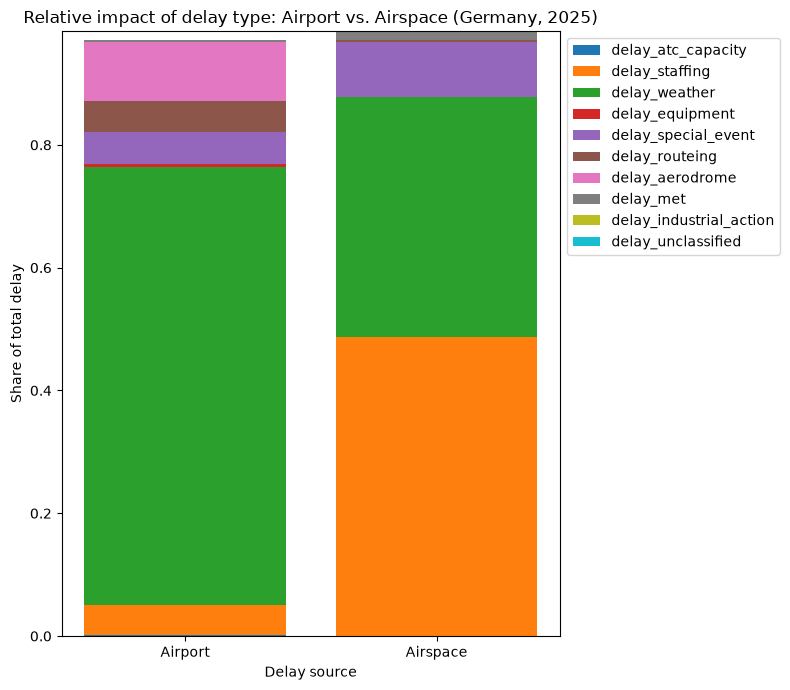

In [31]:
# Comparison delay cause airport vs. delay en-route
# Filter (to set in streamlit)
year_filter = 2025
country_filter = "Germany"

# Delay types
delay_cols = [
    "delay_atc_capacity", "delay_staffing", "delay_weather", "delay_equipment",
    "delay_special_event", "delay_routeing", "delay_aerodrome", "delay_met",
    "delay_industrial_action", "delay_unclassified"
]

# get rows from each df incl. total_delay
airport_row  = df_delay_cause_airport.loc[(country_filter, year_filter)]
airspace_row = df_delay_cause_airspace_year.loc[(country_filter, year_filter)]

# combine rows from the two dfs
df_compare = pd.DataFrame(
    [airport_row[delay_cols], airspace_row[delay_cols]],
    index=["Airport", "Airspace"]
)

# total_delay for airport and airspace
totals = pd.Series(
    [airport_row["total_delay"], airspace_row["total_delay"]],
    index=["Airport", "Airspace"]
)

# normalize
df_compare = df_compare.div(totals, axis=0).fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
bottom = [0] * len(df_compare)
for col in delay_cols:
    ax.bar(df_compare.index, df_compare[col], label=col, bottom=bottom)
    bottom = [b + v for b, v in zip(bottom, df_compare[col].fillna(0))]

ax.set_xlabel("Delay source")
ax.set_ylabel("Share of total delay")
ax.set_title(f"Relative impact of delay type: Airport vs. Airspace ({country_filter}, {year_filter})")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [165]:
def query(sql, **kwargs):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn, **kwargs)

# ── Europe Overview ──────────────────────────────────────────

# ── Airport delay per arrival by country ─────────────
sql_airport_map = """
SELECT
    d.state_name,
    a.iso_country AS iso_a2,
    SUM(d.flt_arr_1) AS total_arrivals,
    SUM(d.dly_apt_arr_1) AS total_delay_min,
    ROUND(SUM(d.dly_apt_arr_1) / NULLIF(SUM(d.flt_arr_1), 0), 4) AS delay_per_arrival
FROM fact_airport_delay d
JOIN dim_airport a ON d.apt_icao = a.ident
WHERE d.year = 2025
  AND d.dly_apt_arr_1 IS NOT NULL
GROUP BY d.state_name, a.iso_country
ORDER BY delay_per_arrival DESC
"""
df_apt_map = query(sql_airport_map)

# ── En-route delay per flight by country ───────────────
sql_enroute_map = """
SELECT
    r.iso_country AS iso_a2,
    r.country_name,
    SUM(e.dly_ert_1) AS total_delay_min,
    SUM(e.flt_ert_1) AS total_flights,
    ROUND(SUM(e.dly_ert_1) / NULLIF(SUM(e.flt_ert_1), 0), 4) AS delay_per_flight
FROM fact_enroute_delay e
JOIN dim_entity_region r ON e.entity_name = r.entity_name
WHERE e.year = 2025
  AND e.entity_type = 'ANSP (AUA)'
  AND e.dly_ert_1 IS NOT NULL
GROUP BY r.iso_country, r.country_name
ORDER BY delay_per_flight DESC
"""
df_ert_map = query(sql_enroute_map)

# ── ISO-2 → ISO-3 Mapping ────────────────────────────────────
ISO2_TO_ISO3 = {
    'AL':'ALB','AM':'ARM','AT':'AUT','AZ':'AZE','BA':'BIH','BE':'BEL',
    'BG':'BGR','BY':'BLR','CH':'CHE','CY':'CYP','CZ':'CZE','DE':'DEU',
    'DK':'DNK','EE':'EST','ES':'ESP','FI':'FIN','FR':'FRA','GB':'GBR',
    'GE':'GEO','GR':'GRC','HR':'HRV','HU':'HUN','IE':'IRL','IL':'ISR',
    'IS':'ISL','IT':'ITA','LT':'LTU','LU':'LUX','LV':'LVA','MD':'MDA',
    'ME':'MNE','MK':'MKD','MT':'MLT','NL':'NLD','NO':'NOR','PL':'POL',
    'PT':'PRT','RO':'ROU','RS':'SRB','SE':'SWE','SI':'SVN','SK':'SVK',
    'TR':'TUR','UA':'UKR',
}
df_apt_map['iso_a3'] = df_apt_map['iso_a2'].map(ISO2_TO_ISO3)
df_ert_map['iso_a3'] = df_ert_map['iso_a2'].map(ISO2_TO_ISO3)

# ── Plot ─────────────────────────────────────────────────────────────

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=[
        "Airport ATFM Delay per Arrival (min)",
        "En-Route ATFM Delay per Flight (min)"
    ]
)

geo_layout = dict(
    showland=True,       landcolor='#d0d0d0',
    showocean=True,      oceancolor='#dceefb',
    showcoastlines=True, coastlinecolor='white',
    showcountries=True,  countrycolor='white',
    projection_type='natural earth',
    center=dict(lat=52, lon=12),
    lataxis_range=[34, 72],
    lonaxis_range=[-25, 45],
)

# Links: Airport
fig.add_trace(go.Choropleth(
    locations=df_apt_map['iso_a3'],
    z=df_apt_map['delay_per_arrival'],
    text=df_apt_map['state_name'],
    colorscale='Reds',
    colorbar=dict(title="min / arrival", x=0.46, len=0.8),
    zmin=0, zmax=df_apt_map['delay_per_arrival'].quantile(0.95),
    hovertemplate="<b>%{text}</b><br>%{z:.4f} min / arrival<extra></extra>",
), row=1, col=1)

# Rechts: En-Route
fig.add_trace(go.Choropleth(
    locations=df_ert_map['iso_a3'],
    z=df_ert_map['delay_per_flight'],
    text=df_ert_map['country_name'],
    colorscale='Blues',
    colorbar=dict(title="min / flight", x=1.02, len=0.8),
    zmin=0, zmax=df_ert_map['delay_per_flight'].quantile(0.95),
    hovertemplate="<b>%{text}</b><br>%{z:.4f} min / flight<extra></extra>",
), row=1, col=2)

fig.update_geos(geo_layout)
fig.update_layout(
    title=dict(
        text="Airport vs. En-Route ATFM Delay by Country (2025)",
        font=dict(size=14), x=0.5
    ),
    height=500,
    margin=dict(l=0, r=0, t=60, b=0),
)

fig.show()

**Key finding:**  
Airport and en-route ATFM delays are driven by fundamentally different factors and affect different countries. A finding that has direct implications for where capacity investments should be targeted.

**Airport (left, red):**  
Greece and the Benelux region stand out (local infrastructure and capacity issues at the airports themselves).

**En-route (right, blue):**  
France and Spain clearly dominate—structural ANSP capacity issues in the airspace, not at the airports.

